In [1]:
!pip uninstall -y numpy albumentations
!pip install numpy==1.26.4 --quiet
!pip install albumentations==1.3.1 --quiet
print("✅ Done — now go to Runtime → Restart and run all")

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Found existing installation: albumentations 1.3.1
Uninstalling albumentations-1.3.1:
  Successfully uninstalled albumentations-1.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 re

In [2]:
# Install dependencies
!pip uninstall -y numpy
!pip install numpy==1.26.4 --quiet
!pip install ultralytics --quiet

import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
from pathlib import Path
import shutil
import time
import yaml
from collections import Counter
from tqdm import tqdm

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_

In [3]:
PROJECT_DIR   = Path('/kaggle/working')
DATASETS_ROOT = Path('/kaggle/input/datasets/ziadyasser1/toysdataset/Datasets')
MERGED_DIR    = PROJECT_DIR / "merged_dataset"
PRE_DIR       = PROJECT_DIR / "preprocessed_dataset"
RUNS_DIR      = PROJECT_DIR / "runs"
MODELS_DIR    = PROJECT_DIR / "models"

CLEAN_RUN    = True
RUN_TRAIN    = True


TRAIN_EPOCHS = 150
TRAIN_BATCH  = 32       
IMG_SIZE     = 320     

class_mapping = {
    'Toy Cars Detection.v10i.yolov5pytorch': {'toy-car': 0},
    'Lego Detector.v1i.yolov5pytorch':       {'lego': 1},
    'Stop Sign.v1i.yolov5pytorch':           {'stop-sign': 2},
    'traffic light.v1i.yolov5pytorch':       {'green': 3, 'red': 4, 'yellow': 5}
}

COMBINED_CLASSES = ['toy-car', 'lego', 'stop-sign', 'green', 'red', 'yellow']
RARE_CLASSES     = [1, 2, 3, 4, 5]
AUGMENT_TIMES    = {1: 3, 2: 3, 3: 3, 4: 3, 5: 3}

In [4]:
def prepare_dirs():
    for p in [PROJECT_DIR, MERGED_DIR, PRE_DIR, RUNS_DIR, MODELS_DIR]:
        p.mkdir(parents=True, exist_ok=True)
    for split in ['train', 'val', 'test']:
        for base in [MERGED_DIR, PRE_DIR]:
            (base / "images" / split).mkdir(parents=True, exist_ok=True)
            (base / "labels" / split).mkdir(parents=True, exist_ok=True)

if CLEAN_RUN:
    if MERGED_DIR.exists(): shutil.rmtree(MERGED_DIR)
    if PRE_DIR.exists():    shutil.rmtree(PRE_DIR)

prepare_dirs()
print("✅ Directories ready.")

✅ Directories ready.


Merging datasets ...

→ Toy Cars Detection.v10i.yolov5pytorch

→ Lego Detector.v1i.yolov5pytorch

→ Stop Sign.v1i.yolov5pytorch

→ traffic light.v1i.yolov5pytorch

✅ Merge done. Total images: 3242


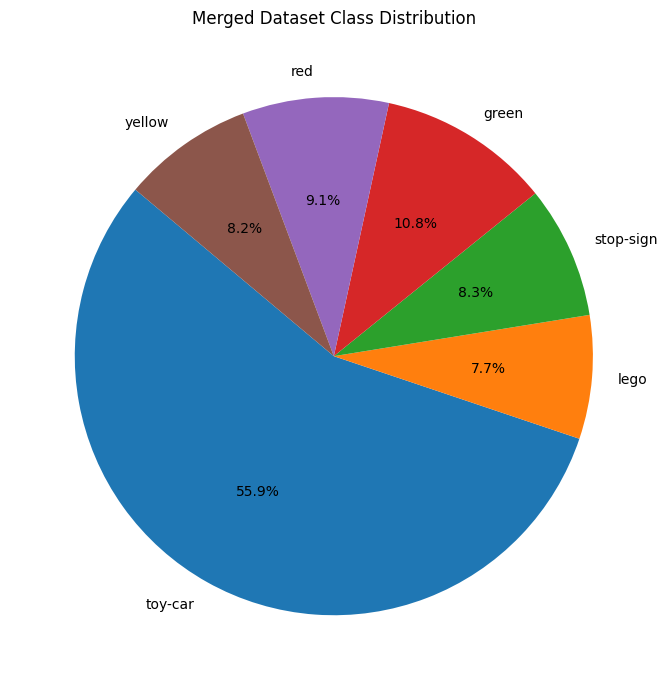

In [5]:
def merge_datasets():
    print("Merging datasets ...")
    image_counter = 0
    class_counts  = Counter()
    folder_map    = {p.name: p for p in DATASETS_ROOT.iterdir() if p.is_dir()}

    for dataset_name, cmap in class_mapping.items():
        dataset_path = DATASETS_ROOT / dataset_name
        if not dataset_path.exists():
            matches      = [p for name, p in folder_map.items()
                            if dataset_name.lower() in name.lower()]
            dataset_path = matches[0] if matches else dataset_path
        print(f"\n→ {dataset_name}")
        if not dataset_path.exists():
            print("  ✗ Not found, skipping.")
            continue

        for split in ['train', 'valid', 'test']:
            merged_split = 'val' if split == 'valid' else split
            labels_path  = dataset_path / split / 'labels'
            images_path  = dataset_path / split / 'images'
            if not labels_path.exists(): continue

            for label_file in labels_path.glob("*.txt"):
                with open(label_file, 'r') as f:
                    lines = f.readlines()

                new_lines = []
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    old_class = int(float(parts[0]))
                    if   dataset_name.lower().startswith('toy'):      new_class = 0
                    elif dataset_name.lower().startswith('lego'):     new_class = 1
                    elif dataset_name.lower().startswith('stop'):     new_class = 2
                    elif dataset_name.lower().startswith('traffic'):  new_class = 3 + old_class
                    else:                                              new_class = old_class
                    new_lines.append(f"{int(new_class)} {' '.join(parts[1:])}\n")
                    class_counts[new_class] += 1

                safe_name    = dataset_name.replace(' ','').replace(':','').replace('.','')
                new_lbl_name = f"{safe_name}_{image_counter:06d}.txt"
                out_label    = MERGED_DIR / "labels" / merged_split / new_lbl_name
                out_label.parent.mkdir(parents=True, exist_ok=True)
                with open(out_label, 'w') as f:
                    f.writelines(new_lines)

                for ext in ['.jpg','.jpeg','.png','.JPG','.JPEG','.PNG']:
                    src_img = images_path / (label_file.stem + ext)
                    if src_img.exists():
                        out_img = MERGED_DIR / "images" / merged_split / f"{safe_name}_{image_counter:06d}{ext}"
                        shutil.copy2(src_img, out_img)
                        image_counter += 1
                        break

    print(f"\n✅ Merge done. Total images: {image_counter}")

    # Class distribution pie chart
    labels = COMBINED_CLASSES
    values = [class_counts[i] for i in range(len(labels))]
    plt.figure(figsize=(7, 7))
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title("Merged Dataset Class Distribution")
    plt.tight_layout()
    plt.show()

merge_datasets()

In [6]:
def letterbox_resize(image, target_size=IMG_SIZE):
    h0, w0     = image.shape[:2]
    scale      = target_size / max(h0, w0)
    newh, neww = int(h0 * scale), int(w0 * scale)
    resized    = cv2.resize(image, (neww, newh), interpolation=cv2.INTER_LINEAR)
    canvas     = np.full((target_size, target_size, 3), 128, dtype=np.uint8)
    top        = (target_size - newh) // 2
    left       = (target_size - neww) // 2
    canvas[top:top + newh, left:left + neww] = resized
    return canvas, scale, left, top, h0, w0, newh, neww

print("✅ Letterbox helper defined.")

✅ Letterbox helper defined.


In [7]:
def preprocess_originals():
    print("Preprocessing images (letterbox resize) ...")
    total = 0
    for split in ['train', 'val', 'test']:
        src_img_dir = MERGED_DIR / "images" / split
        src_lbl_dir = MERGED_DIR / "labels" / split
        dst_img_dir = PRE_DIR    / "images" / split
        dst_lbl_dir = PRE_DIR    / "labels" / split

        for label_file in tqdm(list(src_lbl_dir.glob("*.txt")), desc=f"{split.upper()}"):
            img_path = None
            for ext in ['.jpg','.jpeg','.png','.JPG','.JPEG','.PNG']:
                maybe = src_img_dir / (label_file.stem + ext)
                if maybe.exists(): img_path = maybe; break
            if img_path is None: continue

            img = cv2.imread(str(img_path))
            if img is None: continue

            canvas, scale, left, top, h0, w0, newh, neww = letterbox_resize(img)
            out_lines = []
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    cls  = int(float(parts[0]))
                    x, y, bw, bh = map(float, parts[1:5])
                    x  = np.clip((x  * w0 * scale + left) / IMG_SIZE, 0.0, 1.0)
                    y  = np.clip((y  * h0 * scale + top)  / IMG_SIZE, 0.0, 1.0)
                    bw = np.clip((bw * w0 * scale)         / IMG_SIZE, 0.0, 1.0)
                    bh = np.clip((bh * h0 * scale)         / IMG_SIZE, 0.0, 1.0)
                    out_lines.append(f"{cls} {x:.6f} {y:.6f} {bw:.6f} {bh:.6f}\n")

            cv2.imwrite(str(dst_img_dir / f"{label_file.stem}.jpg"), canvas)
            with open(dst_lbl_dir / f"{label_file.stem}.txt", 'w') as f:
                f.writelines(out_lines)
            total += 1

    print(f"✅ Preprocessing done. {total} images written.")

preprocess_originals()

Preprocessing images (letterbox resize) ...


TEST: 100%|██████████| 152/152 [00:00<00:00, 416.51it/s]

✅ Preprocessing done. 3242 images written.


In [8]:
!pip install albumentations==1.3.1 --quiet
!pip install opencv-python-headless --quiet

import importlib, albumentations
importlib.reload(albumentations)
import albumentations as A

augmenter = A.Compose([
    A.RandomScale(scale_limit=0.2, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=(0, 0.15), contrast_limit=0.15, p=0.4),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=12, val_shift_limit=0, p=0.3),
    A.MotionBlur(blur_limit=3, p=0.2)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def augment_into_preprocessed():
    print("Augmenting rare-class images ...")
    src_img_dir    = MERGED_DIR / "images" / "train"
    src_lbl_dir    = MERGED_DIR / "labels" / "train"
    dst_img_dir    = PRE_DIR    / "images" / "train"
    dst_lbl_dir    = PRE_DIR    / "labels" / "train"
    counter        = 0
    existing_stems = {p.stem for p in dst_img_dir.glob("*.jpg")}

    for label_file in tqdm(list(src_lbl_dir.glob("*.txt")), desc="AUGMENT"):
        with open(label_file, 'r') as f:
            lines = f.readlines()
        classes_here = {int(float(l.split()[0])) for l in lines}
        n_aug = max([AUGMENT_TIMES.get(c, 0) for c in classes_here & set(RARE_CLASSES)], default=0)
        if n_aug == 0: continue

        img_path = None
        for ext in ['.jpg','.jpeg','.png','.JPG','.JPEG','.PNG']:
            maybe = src_img_dir / (label_file.stem + ext)
            if maybe.exists(): img_path = maybe; break
        if img_path is None: continue
        img = cv2.imread(str(img_path))
        if img is None: continue

        bboxes       = [list(map(float, l.strip().split()[1:5])) for l in lines]
        class_labels = [int(float(l.split()[0])) for l in lines]

        for i in range(n_aug):
            aug        = augmenter(image=img, bboxes=bboxes, class_labels=class_labels)
            aug_img    = aug['image']
            canvas, scale, left, top, h0, w0, _, _ = letterbox_resize(aug_img)

            stem = f"{label_file.stem}_aug{i}"
            j = 0
            while stem in existing_stems: j += 1; stem = f"{label_file.stem}_aug{i}_{j}"
            existing_stems.add(stem)

            out_lines = []
            for cls, (x, y, bw, bh) in zip(aug['class_labels'], aug['bboxes']):
                xn  = np.clip((x  * aug_img.shape[1] * scale + left) / IMG_SIZE, 0.0, 1.0)
                yn  = np.clip((y  * aug_img.shape[0] * scale + top)  / IMG_SIZE, 0.0, 1.0)
                bwn = np.clip((bw * aug_img.shape[1] * scale)         / IMG_SIZE, 0.0, 1.0)
                bhn = np.clip((bh * aug_img.shape[0] * scale)         / IMG_SIZE, 0.0, 1.0)
                out_lines.append(f"{cls} {xn:.6f} {yn:.6f} {bwn:.6f} {bhn:.6f}\n")

            cv2.imwrite(str(dst_img_dir / f"{stem}.jpg"), canvas)
            with open(dst_lbl_dir / f"{stem}.txt", 'w') as f:
                f.writelines(out_lines)
            counter += 1

    print(f"✅ Augmentation done. {counter} new images added.")

augment_into_preprocessed()

Augmenting rare-class images ...


AUGMENT: 100%|██████████| 2712/2712 [00:21<00:00, 124.14it/s]

✅ Augmentation done. 4599 new images added.


✅ YAML saved.

Final class counts:
  toy-car: 2822
  lego: 1361
  stop-sign: 1266
  green: 1851
  red: 1669
  yellow: 1496


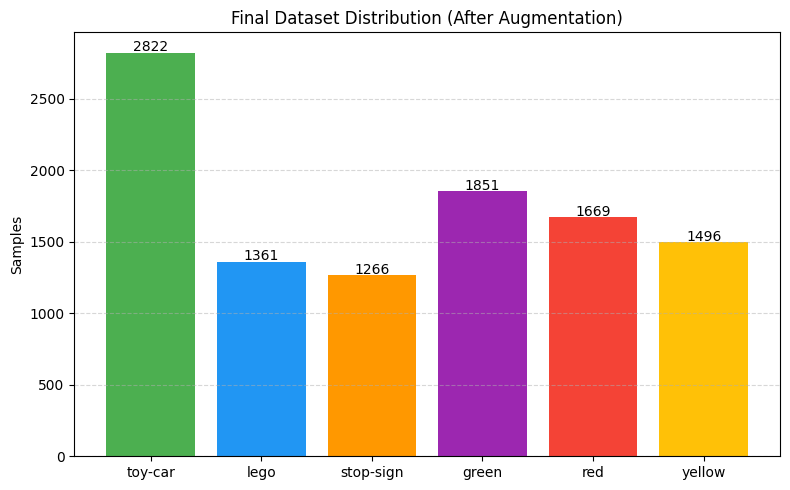

In [9]:
def create_yaml_and_count():
    data_yaml = {
        'path':  str(PRE_DIR.resolve()),
        'train': 'images/train',
        'val':   'images/val',
        'test':  'images/test',
        'nc':    len(COMBINED_CLASSES),
        'names': COMBINED_CLASSES
    }
    yaml_path = PRE_DIR / "preprocessed_dataset.yaml"
    with open(yaml_path, 'w') as f:
        yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

    counts = {i: 0 for i in range(len(COMBINED_CLASSES))}
    for split in ['train', 'val', 'test']:
        for lbl in (PRE_DIR / "labels" / split).glob("*.txt"):
            with open(lbl) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        counts[int(float(parts[0]))] += 1

    print("✅ YAML saved.")
    print("\nFinal class counts:")
    for i, name in enumerate(COMBINED_CLASSES):
        print(f"  {name}: {counts[i]}")

    # Bar chart
    values = [counts[i] for i in range(len(COMBINED_CLASSES))]
    plt.figure(figsize=(8, 5))
    bars = plt.bar(COMBINED_CLASSES, values,
                   color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336','#FFC107'])
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', fontsize=10)
    plt.title("Final Dataset Distribution (After Augmentation)")
    plt.ylabel("Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return yaml_path

yaml_path = create_yaml_and_count()

In [10]:
from pathlib import Path

PRE_DIR = Path("/kaggle/working/preprocessed_dataset")

train_img_dir = PRE_DIR / "images" / "train"
train_lbl_dir = PRE_DIR / "labels" / "train"

num_images = len(list(train_img_dir.glob("*.jpg")))
num_labels = len(list(train_lbl_dir.glob("*.txt")))

print("Preprocessed dataset status:")
print(f"Images in train/ : {num_images}")
print(f"Labels  in train/ : {num_labels}")


Preprocessed dataset status:
Images in train/ : 7311
Labels  in train/ : 7311


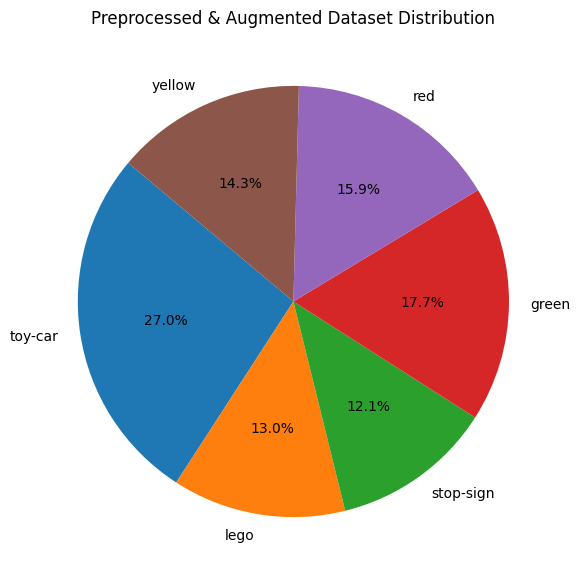

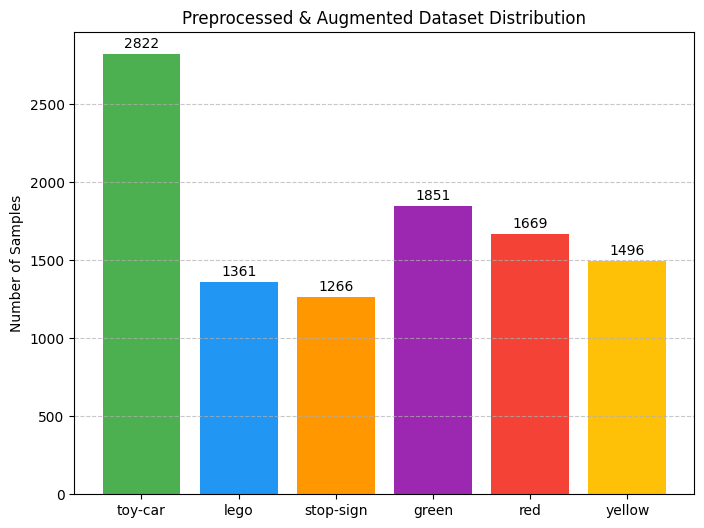

In [11]:
import matplotlib.pyplot as plt

def plot_class_distribution(counts, title="Class Distribution"):
    class_labels = COMBINED_CLASSES  # ["toy-car","lego","stop-sign","green","red","yellow"]
    values = [counts[i] for i in range(len(class_labels))]

    # Pie chart
    plt.figure(figsize=(7,7))
    plt.pie(values, labels=class_labels, autopct='%1.1f%%', startangle=140)
    plt.title(title)
    plt.show()

    # Bar chart (optional, looks cleaner in presentations)
    plt.figure(figsize=(8,6))
    bars = plt.bar(class_labels, values, color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336','#FFC107'])
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', va='bottom', fontsize=10)
    plt.title(title)
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# After preprocessing + augmentation, reuse your counts
counts = {i:0 for i in range(len(COMBINED_CLASSES))}
for split in ['train','val','test']:
    for lbl in (PRE_DIR / "labels" / split).glob("*.txt"):
        with open(lbl,'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls = int(float(parts[0]))
                counts[cls] += 1

# Plot updated distribution
plot_class_distribution(counts, title="Preprocessed & Augmented Dataset Distribution")


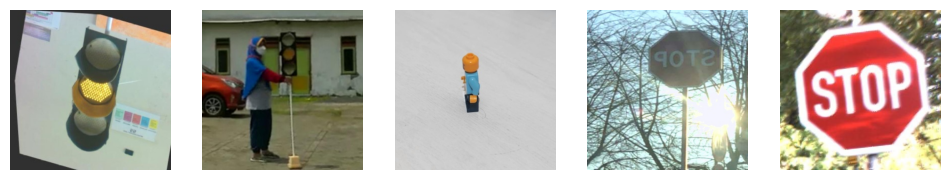

In [12]:
import matplotlib.pyplot as plt
import cv2
import random

sample_imgs = list(train_img_dir.glob("*.jpg"))
random.shuffle(sample_imgs)
sample_imgs = sample_imgs[:5]

plt.figure(figsize=(12,8))
for i, img_path in enumerate(sample_imgs):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()


In [13]:
from ultralytics import YOLO
import torch, time, shutil
from pathlib import Path

def train_from_scratch(yaml_path):
    print("=" * 55)
    print("  Training YOLOv8n FROM SCRATCH")
    print("=" * 55)

    run_name = f"yolov8n_scratch_{int(time.time())}"
    model    = YOLO('yolov8n.yaml')

    model.train(
        data=str(yaml_path),
        epochs=TRAIN_EPOCHS,
        batch=TRAIN_BATCH,
        imgsz=IMG_SIZE,
        pretrained=False,
        optimizer='SGD',
        lr0=0.01,
        lrf=0.01,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=5,
        mosaic=1.0,
        mixup=0.1,
        degrees=5.0,
        translate=0.1,
        scale=0.3,
        flipud=0.01,
        fliplr=0.5,
        patience=20,
        conf=0.001,
        iou=0.7,
        amp=True,
        device=0 if torch.cuda.is_available() else 'cpu',
        name=run_name,
        verbose=True,
    )

    weights_path = Path("/kaggle/working/runs/detect") / run_name / "weights" / "best.pt"
    target_path  = MODELS_DIR / "best.pt"

    if weights_path.exists():
        shutil.copy2(weights_path, target_path)
        print(f"\n✅ Best weights saved → {target_path}")
    else:
        print("⚠️ best.pt not found in run folder.")

    return target_path

if RUN_TRAIN:
    best_weights = train_from_scratch(yaml_path)
else:
    best_weights = MODELS_DIR / "best.pt"
    print("RUN_TRAIN=False, skipping.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  Training YOLOv8n FROM SCRATCH
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=0.001, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/preprocessed_dataset/preprocessed_dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.01, format=torchscript, fraction=1.

In [24]:
import shutil, zipfile
from pathlib import Path

def find_file(partial_name, search_dirs):
    for d in search_dirs:
        if not d.exists(): continue
        for f in d.rglob("*"):
            if f.is_file() and partial_name.lower() in f.name.lower():
                return f
    return None

def find_dir(partial_name, search_dirs):
    for d in search_dirs:
        if not d.exists(): continue
        for f in d.rglob("*"):
            if f.is_dir() and partial_name.lower() in f.name.lower():
                return f
    return None

SEARCH_DIRS = [MODELS_DIR, Path('/kaggle/working'), Path('/kaggle/working/runs')]

save_dir = Path('/kaggle/working/rpi_deployment')
save_dir.mkdir(exist_ok=True)

# 1. best.pt
pt = MODELS_DIR / "best.pt"
if pt.exists():
    shutil.copy2(pt, save_dir / "best.pt")
    print(f"✅ best.pt  ({pt.stat().st_size/1e6:.1f} MB)")
else:
    print("⚠️  best.pt not found")

# 2. NCNN folder
ncnn_dir = find_dir("ncnn", SEARCH_DIRS)
if ncnn_dir:
    dst = save_dir / "best_ncnn_model"
    if dst.exists(): shutil.rmtree(dst)
    shutil.copytree(ncnn_dir, dst)
    sizes = {f.name: f"{f.stat().st_size/1e6:.1f} MB"
             for f in ncnn_dir.iterdir() if f.is_file()}
    print(f"✅ NCNN folder  {sizes}")
else:
    print("⚠️  NCNN folder not found")

# 3. ONNX
onnx = find_file(".onnx", SEARCH_DIRS)
if onnx:
    shutil.copy2(onnx, save_dir / "best.onnx")
    print(f"✅ best.onnx  ({onnx.stat().st_size/1e6:.1f} MB)")
else:
    print("⚠️  ONNX not found")

# 4. YAML
yaml_src = PRE_DIR / "preprocessed_dataset.yaml"
if yaml_src.exists():
    shutil.copy2(yaml_src, save_dir / "dataset.yaml")
    print("✅ dataset.yaml")

# Summary
print(f"\n📁 rpi_deployment/")
for item in sorted(save_dir.rglob("*")):
    indent = "  " * (len(item.relative_to(save_dir).parts) - 1)
    size   = f"({item.stat().st_size/1e6:.1f} MB)" if item.is_file() else ""
    print(f"  {indent}{item.name} {size}")

# Zip
zip_path = Path('/kaggle/working/rpi_deployment.zip')
print("\nZipping...")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for file in sorted(save_dir.rglob("*")):
        if file.is_file():
            zf.write(file, file.relative_to(save_dir))
            print(f"  + {file.relative_to(save_dir)}")

print(f"\n✅ rpi_deployment.zip  ({zip_path.stat().st_size/1e6:.1f} MB)")
print("📥 Kaggle sidebar → Output tab → rpi_deployment.zip → Download")

✅ best.pt  (6.2 MB)
✅ NCNN folder  {'metadata.yaml': '0.0 MB', 'model.ncnn.param': '0.0 MB', 'model_ncnn.py': '0.0 MB', 'model.ncnn.bin': '6.0 MB'}
✅ best.onnx  (6.1 MB)
✅ dataset.yaml

📁 rpi_deployment/
  best.onnx (6.1 MB)
  best.pt (6.2 MB)
  best_ncnn_model 
    __pycache__ 
      model_pnnx.cpython-312.pyc (0.0 MB)
    metadata.yaml (0.0 MB)
    model.ncnn.bin (6.0 MB)
    model.ncnn.param (0.0 MB)
    model_ncnn.py (0.0 MB)
  dataset.yaml (0.0 MB)

Zipping...
  + best.onnx
  + best.pt
  + best_ncnn_model/__pycache__/model_pnnx.cpython-312.pyc
  + best_ncnn_model/metadata.yaml
  + best_ncnn_model/model.ncnn.bin
  + best_ncnn_model/model.ncnn.param
  + best_ncnn_model/model_ncnn.py
  + dataset.yaml

✅ rpi_deployment.zip  (16.7 MB)
📥 Kaggle sidebar → Output tab → rpi_deployment.zip → Download


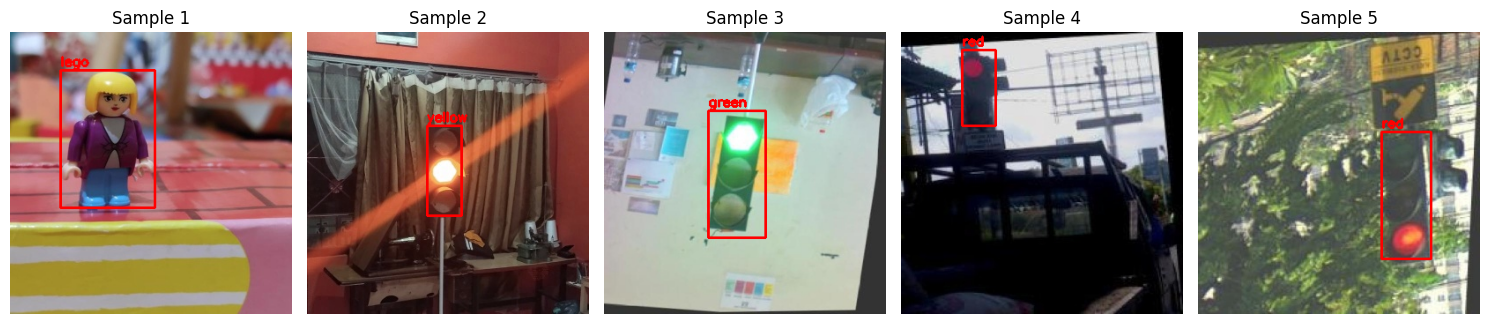

In [25]:
# ------------------------- VISUALIZE PREPROCESSED DATA -----------------------
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Directories
train_img_dir = PRE_DIR / "images" / "train"
train_lbl_dir = PRE_DIR / "labels" / "train"

# Pick random samples
sample_imgs = list(train_img_dir.glob("*.jpg"))
random.shuffle(sample_imgs)
sample_imgs = sample_imgs[:5]  # show 5 images

plt.figure(figsize=(15, 8))

for i, img_path in enumerate(sample_imgs):
    # Load image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Load corresponding label
    lbl_path = train_lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        with open(lbl_path, "r") as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls = int(parts[0])
                x, y, w, h = map(float, parts[1:5])
                # Convert YOLO format back to pixel coordinates
                H, W = img.shape[:2]
                x1 = int((x - w/2) * W)
                y1 = int((y - h/2) * H)
                x2 = int((x + w/2) * W)
                y2 = int((y + h/2) * H)
                # Draw bounding box
                cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)
                cv2.putText(img, COMBINED_CLASSES[cls], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

    # Show image
    plt.subplot(1, len(sample_imgs), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Sample {i+1}")

plt.tight_layout()
plt.show()


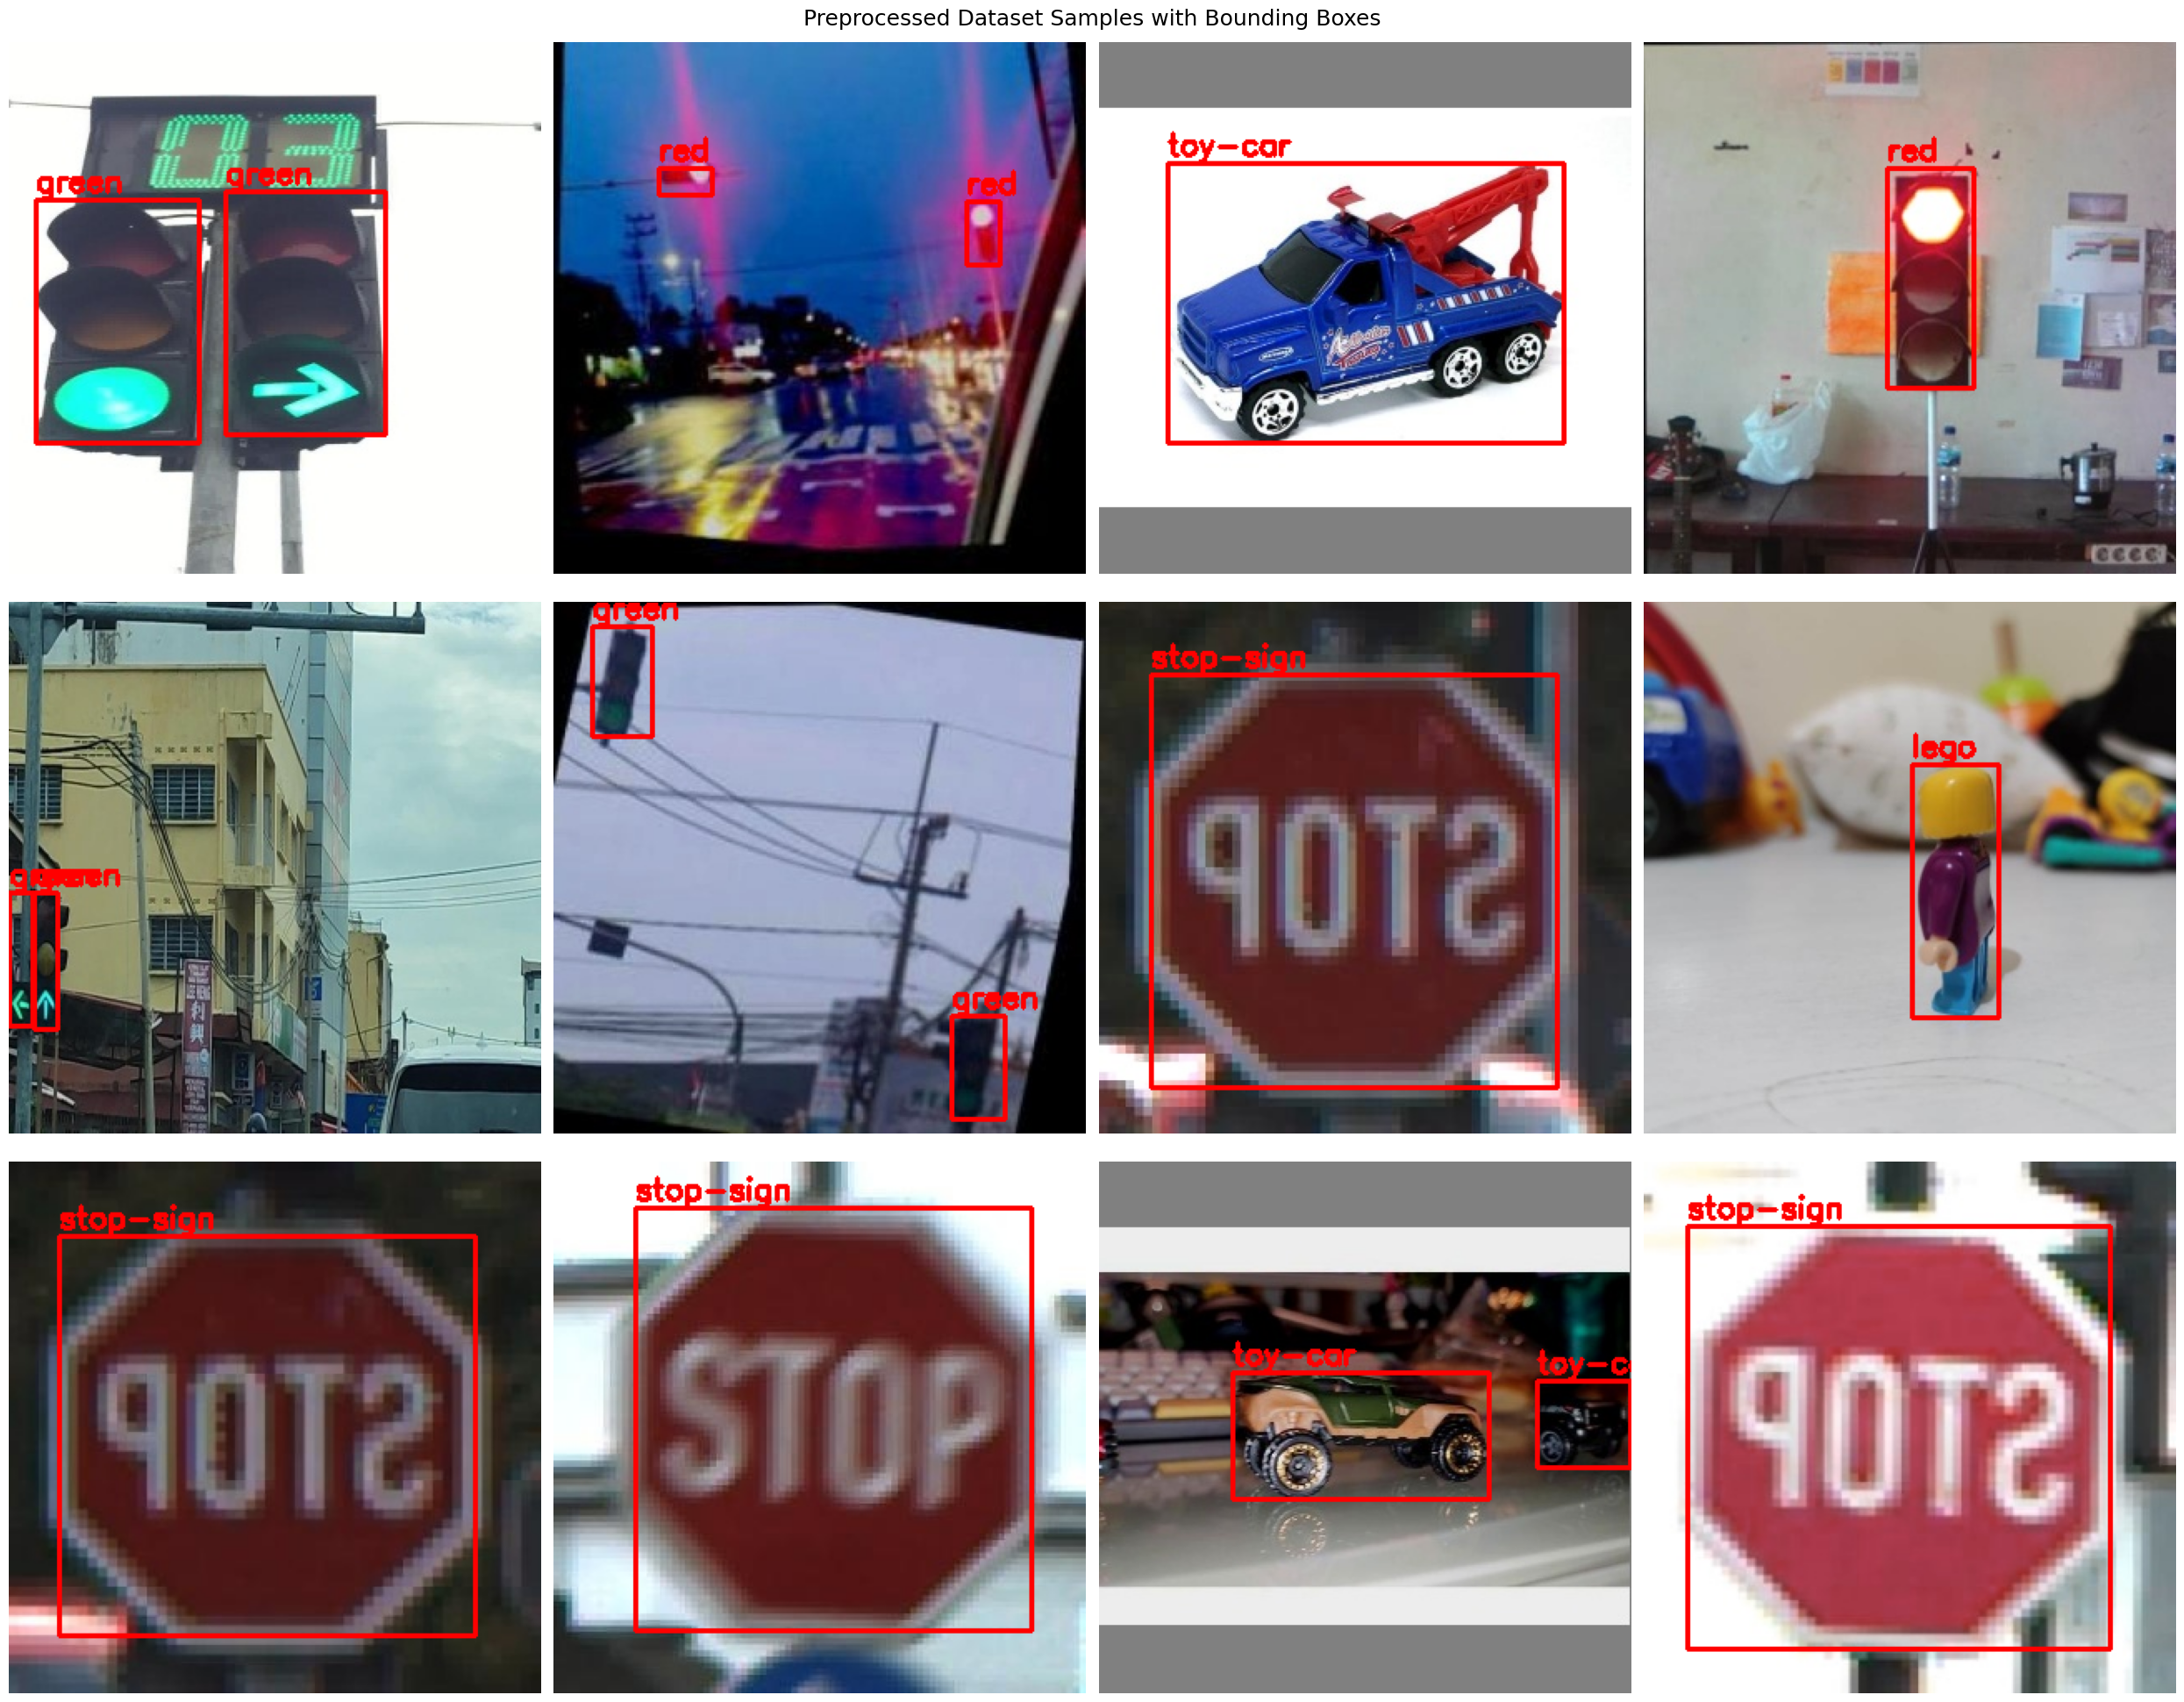

In [26]:
# ------------------------- VISUALIZE MORE PREPROCESSED DATA -----------------------
import random
import cv2
import matplotlib.pyplot as plt

# Directories
train_img_dir = PRE_DIR / "images" / "train"
train_lbl_dir = PRE_DIR / "labels" / "train"

# Pick random samples (e.g., 12 images)
sample_imgs = list(train_img_dir.glob("*.jpg"))
random.shuffle(sample_imgs)
sample_imgs = sample_imgs[:12]  # show 12 samples

# Set up grid (3 rows x 4 columns)
plt.figure(figsize=(25, 20))

for i, img_path in enumerate(sample_imgs):
    # Load image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Load corresponding label file
    lbl_path = train_lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        with open(lbl_path, "r") as f:
            lines = f.readlines()

        h, w = img.shape[:2]
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls = int(parts[0])
            x, y, bw, bh = map(float, parts[1:5])

            # Convert normalized YOLO coords back to pixel coords
            cx, cy = int(x * w), int(y * h)
            bw, bh = int(bw * w), int(bh * h)
            x1, y1 = cx - bw // 2, cy - bh // 2
            x2, y2 = cx + bw // 2, cy + bh // 2

            # Draw bounding box
            cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)
            cv2.putText(img, COMBINED_CLASSES[cls], (x1, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

    # Plot image in grid
    plt.subplot(3, 4, i+1)  # 3 rows, 4 columns
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Preprocessed Dataset Samples with Bounding Boxes", fontsize=18)
plt.tight_layout()
plt.show()


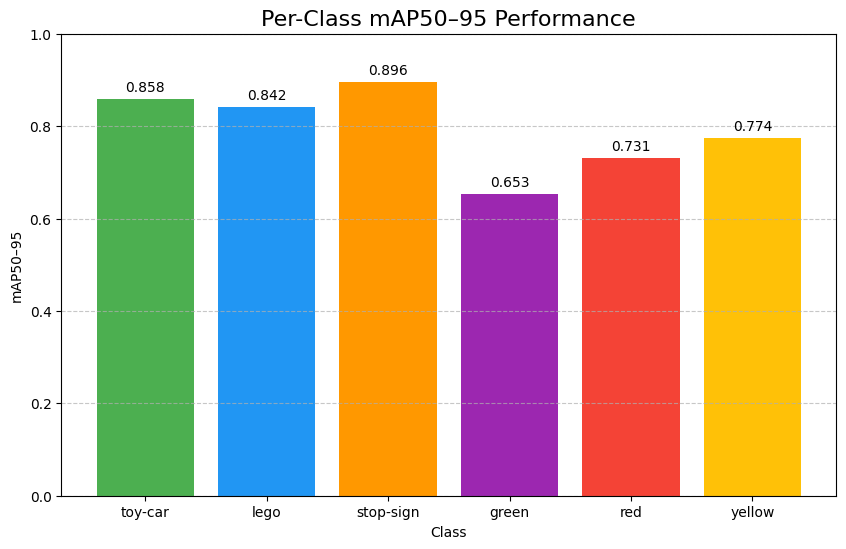

In [27]:
# ------------------------- VISUALIZE PER-CLASS mAP -----------------------
import matplotlib.pyplot as plt

# Per-class mAP50-95 values from your final validation
class_names = ["toy-car", "lego", "stop-sign", "green", "red", "yellow"]
map_values = [0.858, 0.842, 0.896, 0.653, 0.731, 0.774]

plt.figure(figsize=(10,6))
bars = plt.bar(class_names, map_values, color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336','#FFC107'])

# Annotate each bar with its value
for bar, val in zip(bars, map_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha='center', va='bottom', fontsize=10)

plt.ylim(0,1)
plt.title("Per-Class mAP50–95 Performance", fontsize=16)
plt.xlabel("Class")
plt.ylabel("mAP50–95")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


 Latest YOLO run folder: /kaggle/working/runs/detect/yolov8n_scratch_1779025842


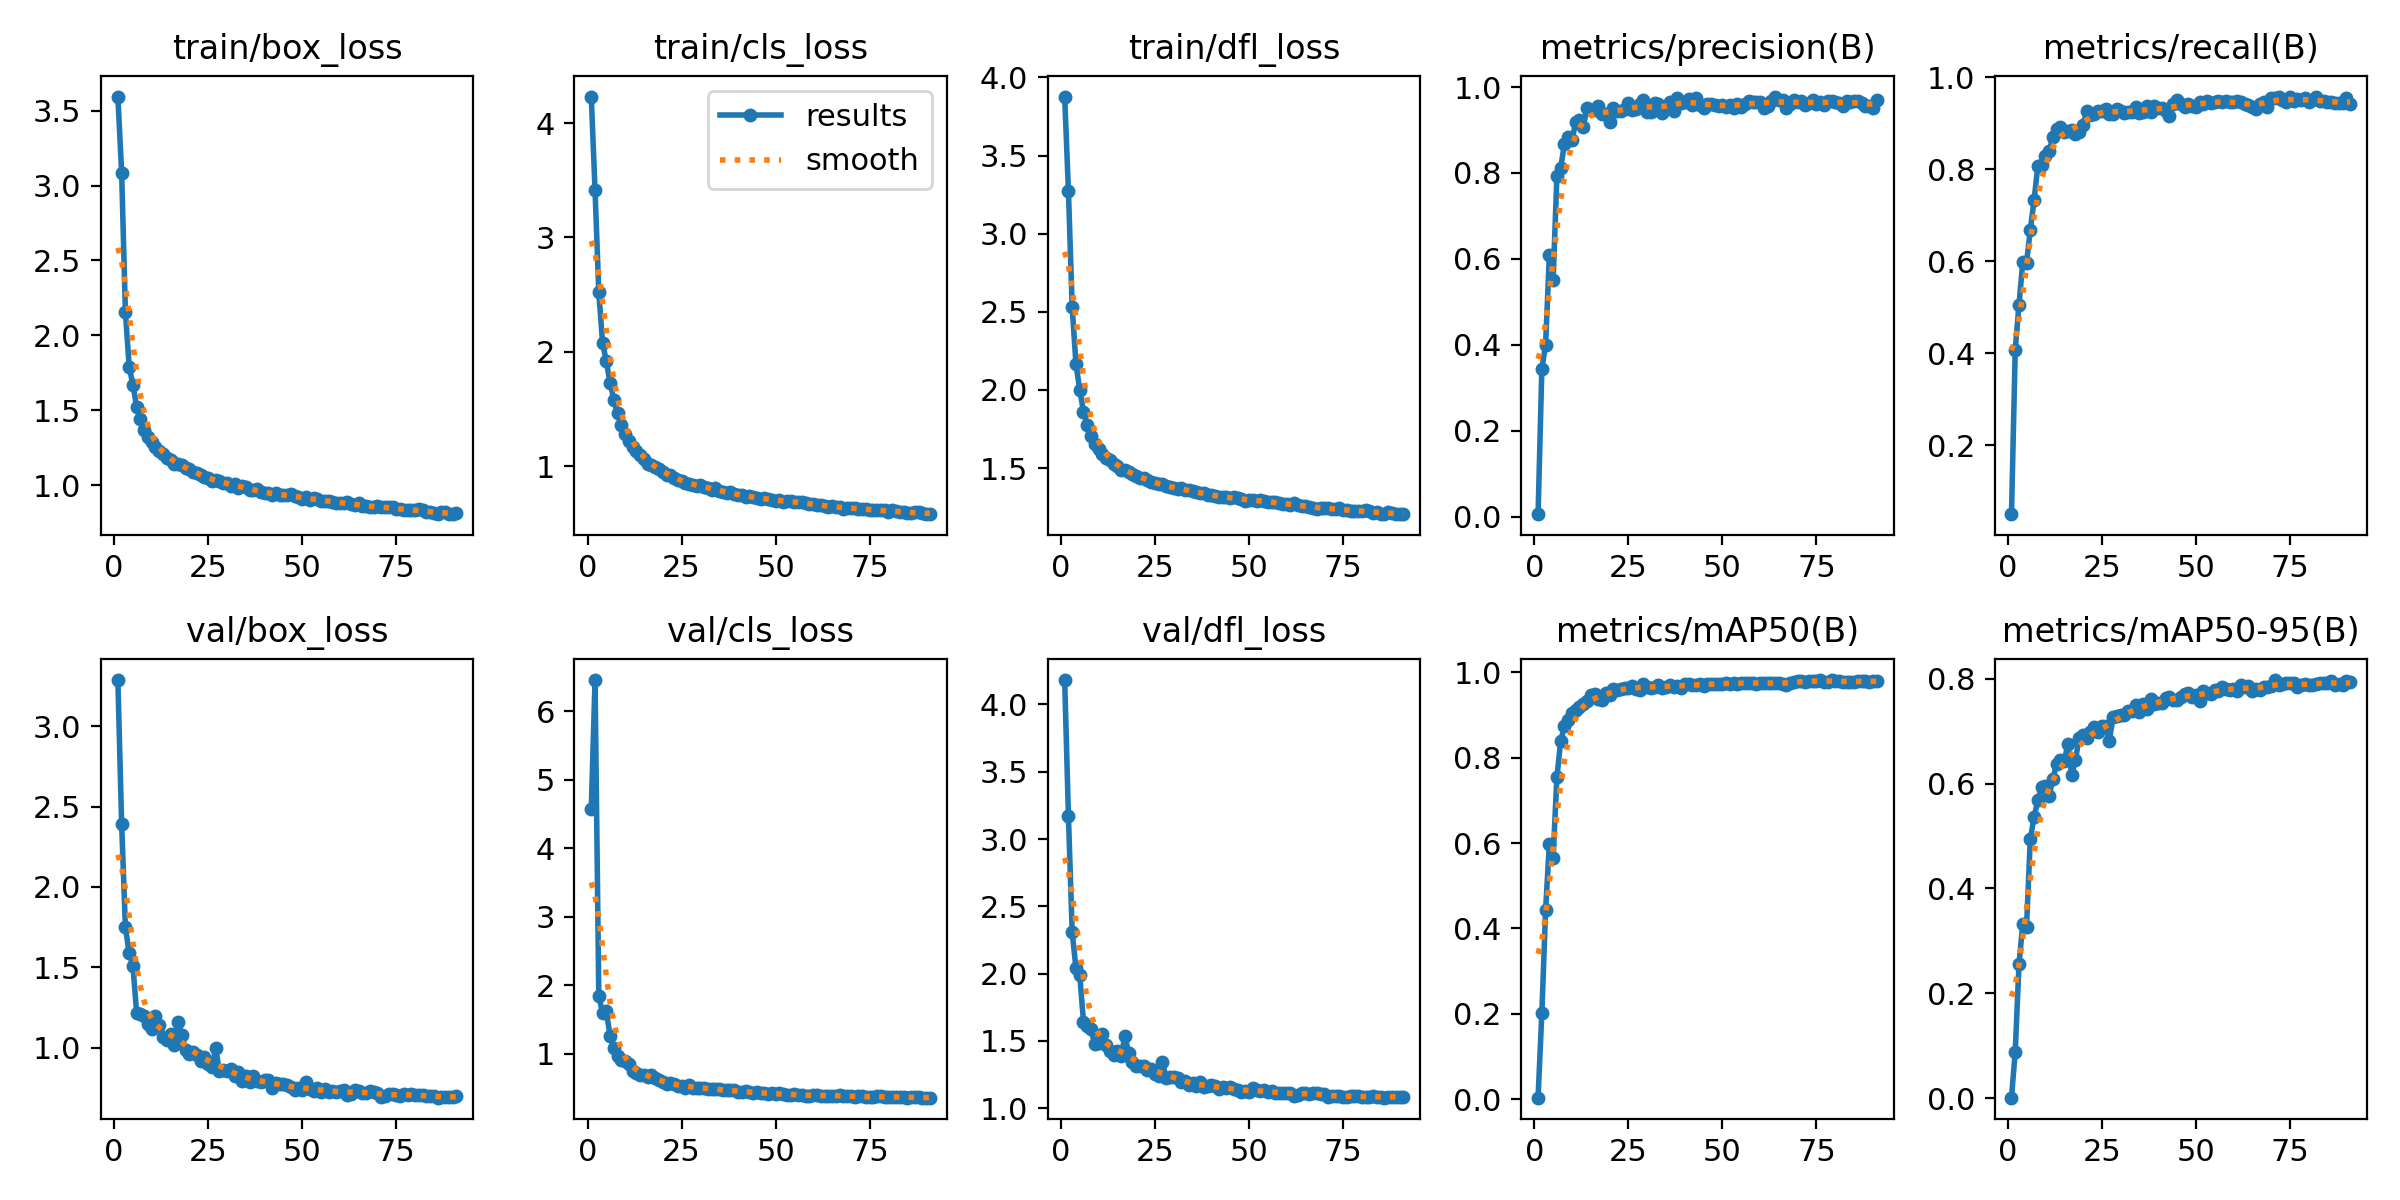

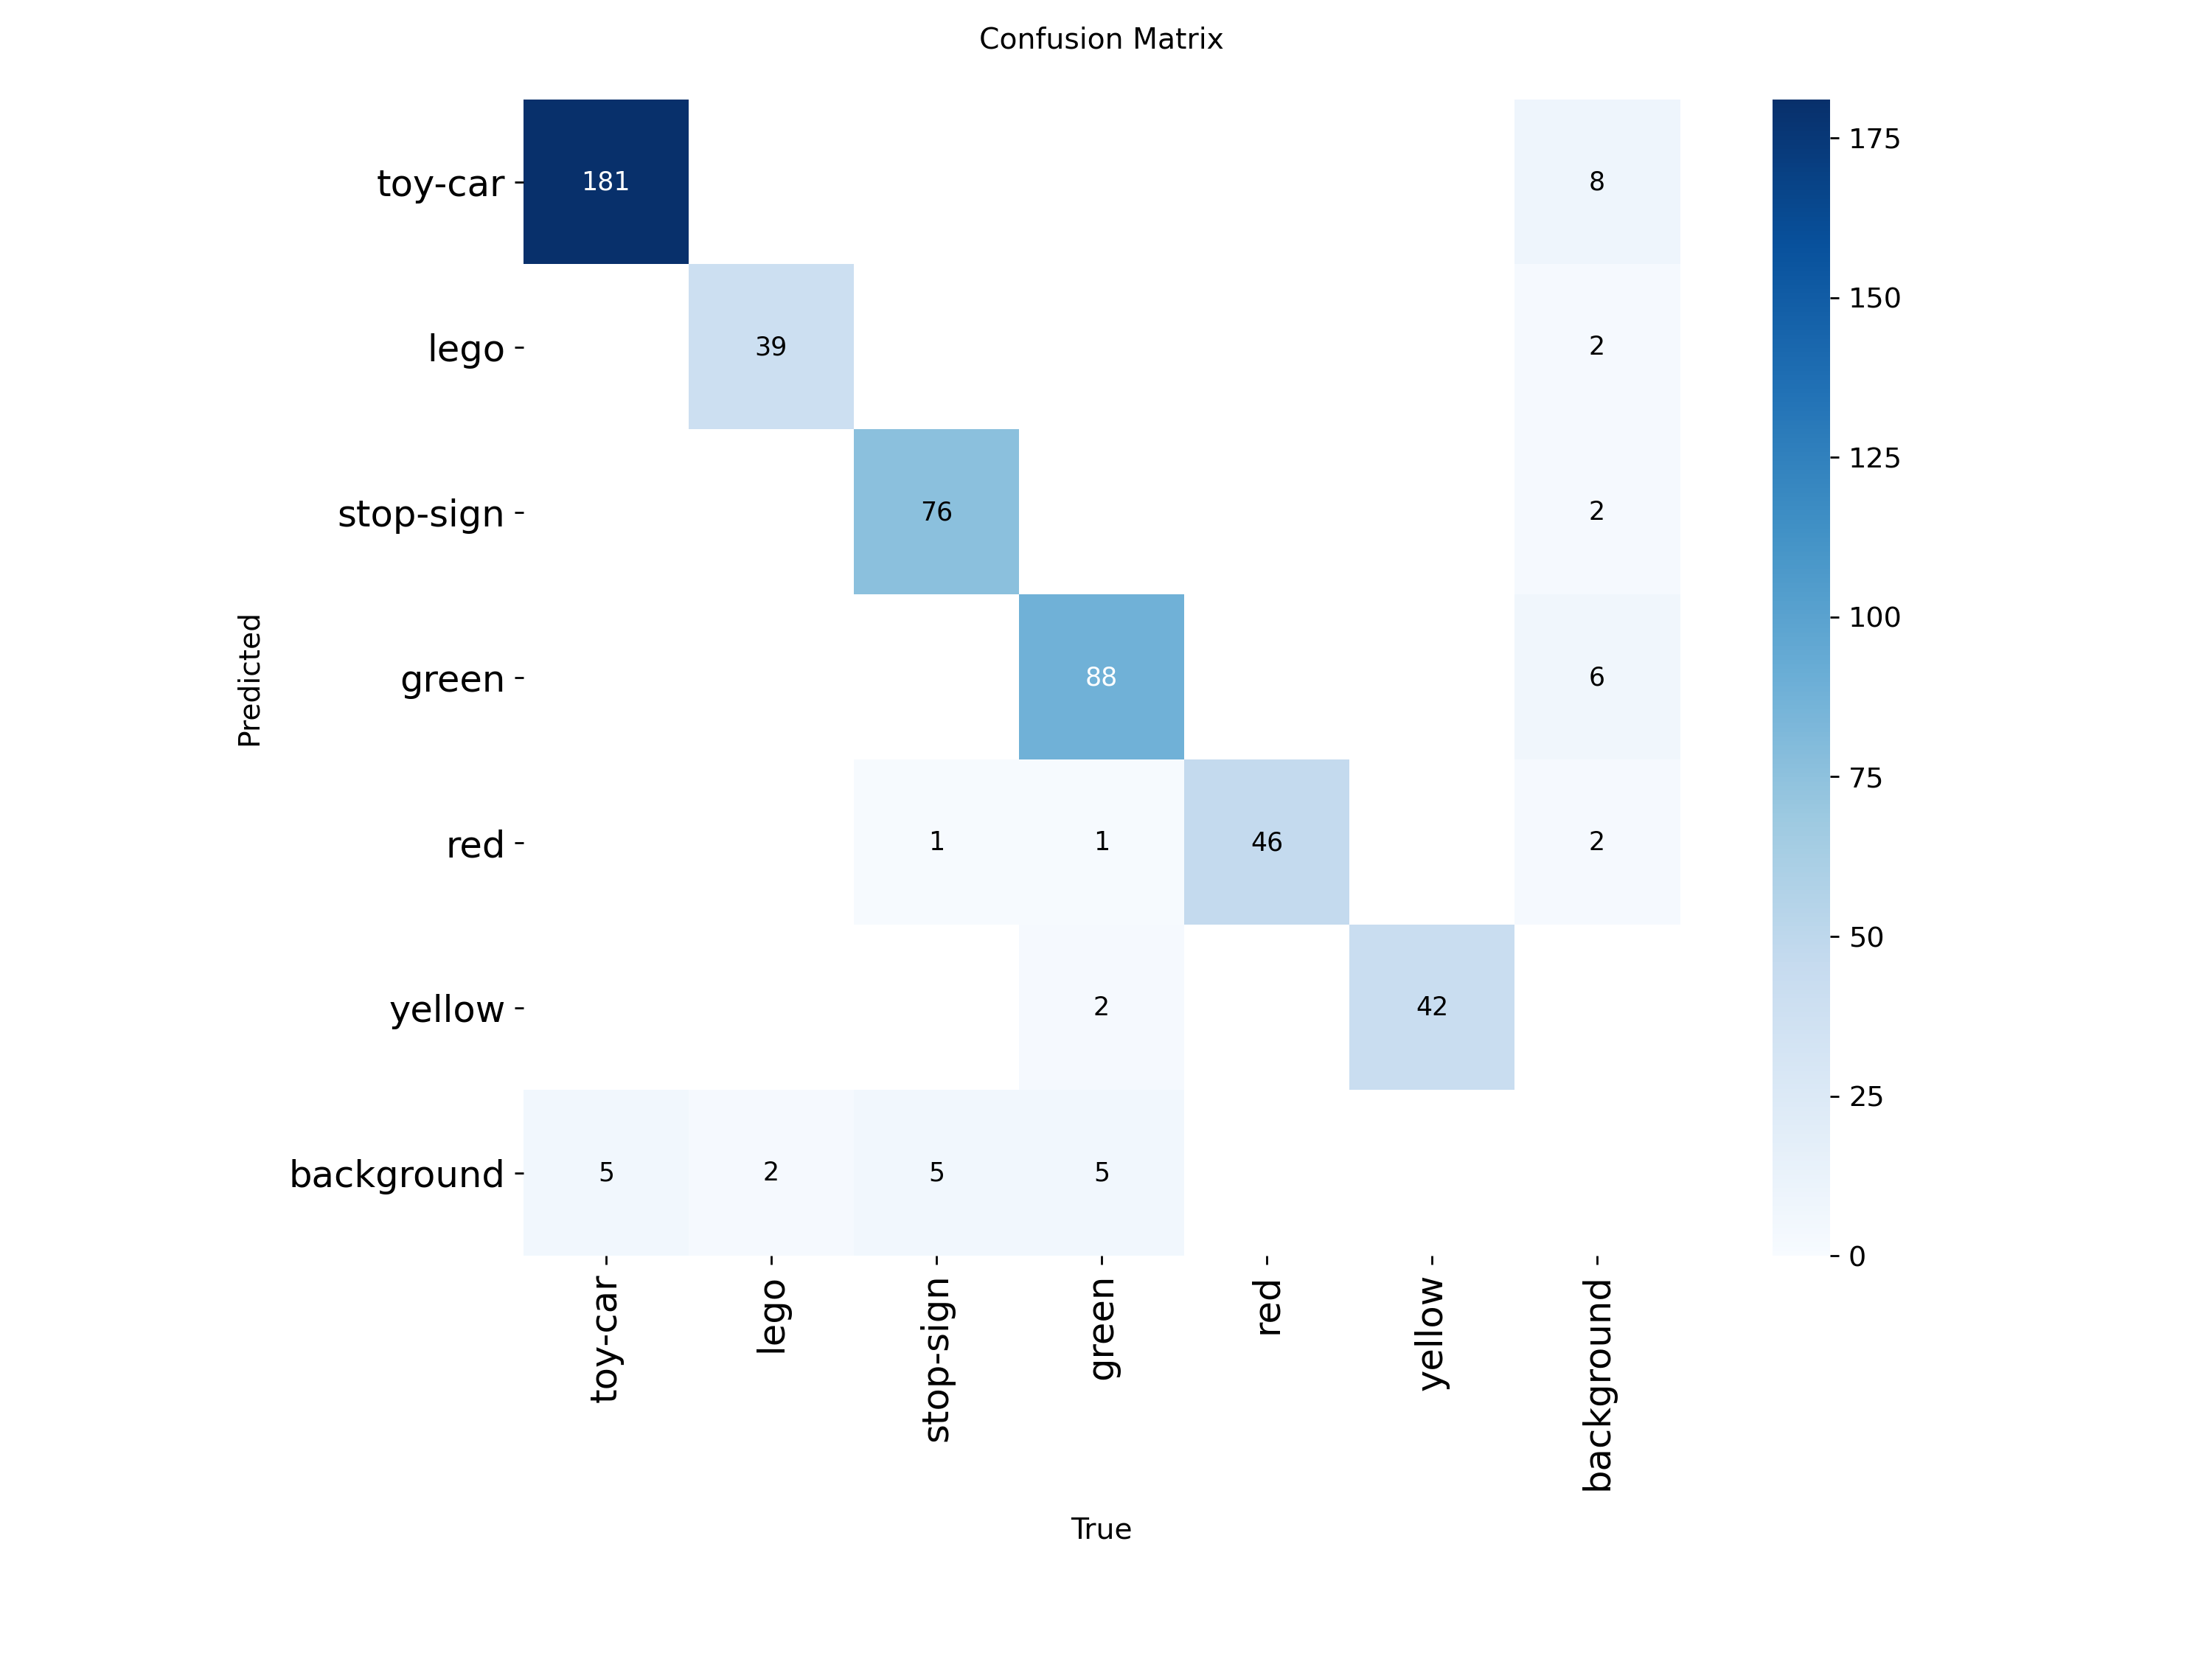

Missing: PR_curve.png
Missing: F1_curve.png


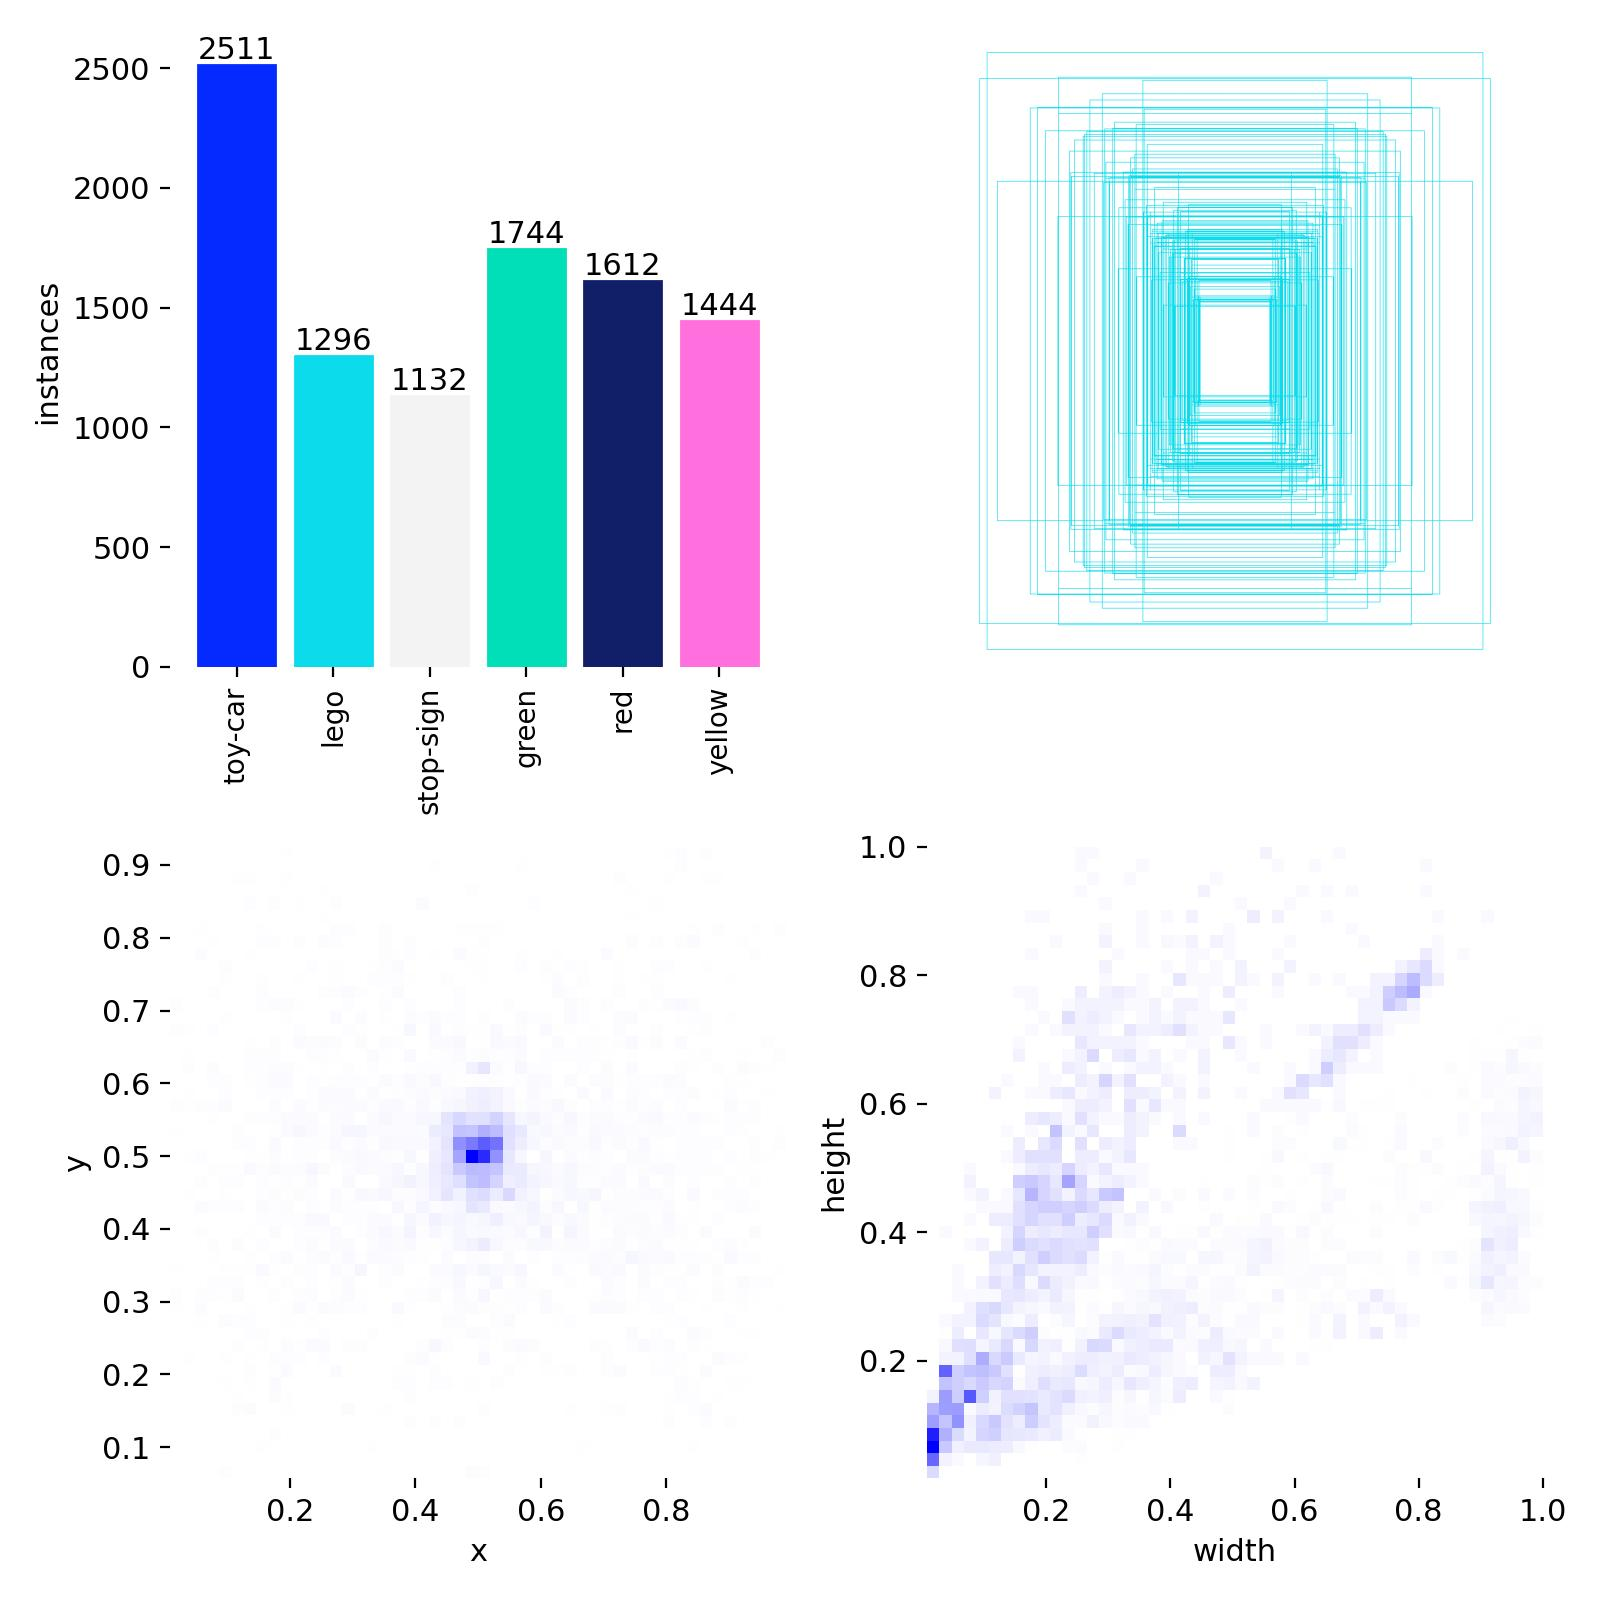

In [28]:
import os
from IPython.display import Image, display

run_dir = "/kaggle/working/runs/detect"  # YOLO output folder

# Get the most recent run automatically
latest_run = sorted(os.listdir(run_dir))[-1]
latest_path = os.path.join(run_dir, latest_run)

print(" Latest YOLO run folder:", latest_path)

# Display important result images
images_to_show = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "labels.jpg"
]

for img_file in images_to_show:
    img_path = os.path.join(latest_path, img_file)
    if os.path.exists(img_path):
        display(Image(filename=img_path))
    else:
        print(f"Missing: {img_file}")

In [29]:
import os
import shutil

# Base directory where YOLO saves runs
run_base = "/kaggle/working/runs/detect"

# Get the most recent run folder
latest_run = sorted(os.listdir(run_base))[-1]
run_folder = os.path.join(run_base, latest_run)

# Output ZIP file
output_zip = "/kaggle/working/yolo_training_results.zip"

# Create ZIP archive of the latest run
shutil.make_archive("/kaggle/working/yolo_training_results", 'zip', run_folder)

print("✅ ZIP file created:", output_zip)
print("📂 Archived run folder:", run_folder)


✅ ZIP file created: /kaggle/working/yolo_training_results.zip
📂 Archived run folder: /kaggle/working/runs/detect/yolov8n_scratch_1779025842


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your training results
csv_path = "/kaggle/working/runs/detect/yolov8n_scratch_1779025842/results.csv"

# Load results
df = pd.read_csv(csv_path)

df.head()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,29.8294,3.59415,4.23166,3.87802,0.00556,0.05003,0.00390,0.00092,3.28776,4.58130,4.18170,0.001991,0.001991,0.082079
1,2,56.9229,3.08667,3.41384,3.27313,0.34379,0.40799,0.20204,0.08865,2.39271,6.45887,3.16933,0.003965,0.003965,0.064052
2,3,83.1145,2.15614,2.52063,2.52869,0.40032,0.50566,0.44284,0.25550,1.74889,1.84497,2.30646,0.005912,0.005912,0.045999
3,4,108.5120,1.79128,2.07955,2.16546,0.60860,0.59803,0.59867,0.33225,1.58966,1.60012,2.03908,0.007833,0.007833,0.027920
4,5,134.1540,1.66787,1.91631,2.00231,0.55035,0.59653,0.56581,0.32661,1.50760,1.62192,1.99068,0.009728,0.009728,0.009815


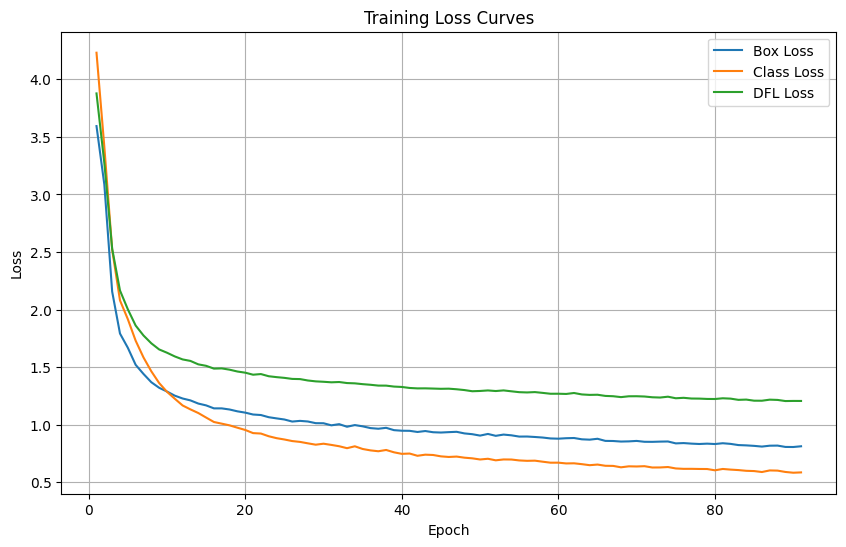

In [32]:
plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['train/box_loss'], label='Box Loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='Class Loss')
plt.plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid()
plt.show()


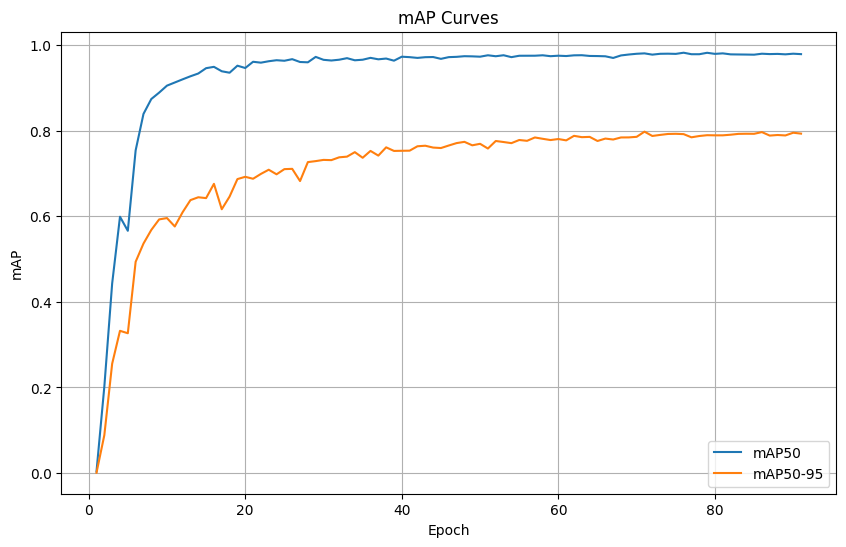

In [33]:
plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP Curves")
plt.legend()
plt.grid()
plt.show()


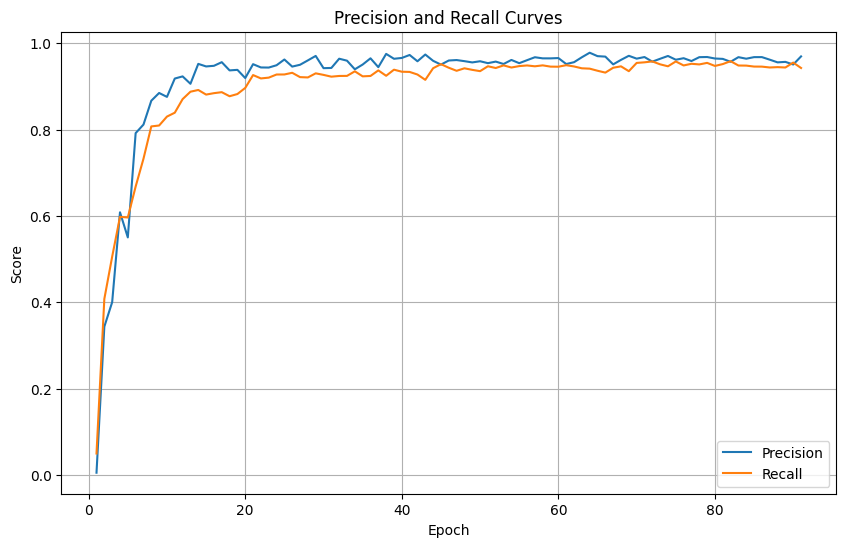

In [34]:
plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision and Recall Curves")
plt.legend()
plt.grid()
plt.show()
